# Detection Frequency & Detectability — US + Global

Power Plant NOx Emissions vs TROPOMI Observation Frequency, 4-panel figure:
(a, b) U.S. (top-500 plants, 6-year complete, interference-filtered)
(c, d) Global (top-6000 plants, interference-filtered)

Paper revision: paths point to the **100 m wind** versions everywhere
(US: LST-fixed augment_localtz; World: 2026-04-28 100 m re-labelling).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.colors as mcolors
import numpy as np
import matplotlib
from sklearn.neighbors import BallTree
from haversine import haversine, Unit
from math import radians, log10
from tqdm import tqdm
import os

# =========================
# Constants / styling
# =========================
EARTH_RADIUS_KM = 6371.0
PLANT_RADIUS_BASE_KM = 20.0           # plant interference threshold
PLANT_MAX_SEARCH_KM = 150.0           # search window for BallTree
CITY_POP_THRESHOLD = 200000
CITY_RADIUS_SCALE = 9.0
CITY_RADIUS_BASE_KM = 10.0
CITY_RADIUS_MAX_KM = 90.0
US_YEARS = [2019, 2020, 2021, 2022, 2023, 2024]

plt.rcdefaults()
plt.rcParams['font.family'] = 'Nimbus Roman'
plt.rcParams['figure.facecolor'] = 'white'

# =========================
# Paths (paper revision, 100 m wind everywhere)
# =========================
# US: 2026-04-28 LST-fixed augment_final_table.py output (100 m ERA5 wind for
# plume direction + LST hour-of-day key for the EPA NOx join).
US_HOURLY_CSV     = '/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv'
US_FACILITY_CSV   = '/net/fs06/d3/rzhuang/TROPOMI/data/us/facility_emissions_by_plant_comprehensive.csv'
US_ANNUAL_CSV     = '/net/fs06/d3/rzhuang/TROPOMI/data/us/annual-emissions-facility-aggregation-2019-2024.csv'

# World: 2026-04-28 100 m re-labelling stage-2 output (ERA5 100 m wind, replaces
# the 10 m TROPOMI-embedded wind used by Run_3). Stage-2 only — only `location`
# and `plume_label` columns are needed for this figure.
WORLD_EMIT_CSV    = '/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/Run_100m_20260428/valid_tropomi_emissions_with_qa.csv'
WORLD_LOC_CSV     = '/net/fs06/d3/rzhuang/TROPOMI/data/world/power_plant_location/power_plants_with_combined_nearby_stats.csv'
WORLD_CITIES_CSV  = '/net/fs06/d3/rzhuang/TROPOMI/data/world/worldcities.csv'

OUTPUT_DIR        = '/net/fs06/d3/rzhuang/TROPOMI/results/paper_figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [2]:
# =========================
# Helpers
# =========================
def _process_source_dataframe(df_raw, lat_col, lon_col, id_col=None, value_col=None):
    if df_raw is None or df_raw.empty:
        return None, None
    df = df_raw.copy()
    std_lat, std_lon, std_id, std_value = 'latitude', 'longitude', 'ID', 'value'
    col_map = {lat_col: std_lat, lon_col: std_lon}
    if id_col: col_map[id_col] = std_id
    if value_col: col_map[value_col] = std_value
    df = df[list(col_map.keys())].rename(columns=col_map)
    for c in [std_lat, std_lon, std_value]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    df.dropna(subset=[std_lat, std_lon], inplace=True)
    if df.empty:
        return df, None
    df['lat_rad'] = np.radians(df[std_lat])
    df['lon_rad'] = np.radians(df[std_lon])
    tree = BallTree(df[['lat_rad', 'lon_rad']].values, metric='haversine')
    return df, tree

def identify_us_interference_one_year(plants_year_df, cities_df):
    """plants_year_df columns required:
      - 'Facility ID', 'Latitude', 'Longitude', 'NOx Mass (short tons)'
    """
    source_plants_df, plant_tree = _process_source_dataframe(
        plants_year_df, 'Latitude', 'Longitude',
        id_col='Facility ID', value_col='NOx Mass (short tons)'
    )
    source_cities_df, city_tree = _process_source_dataframe(
        cities_df, 'latitude', 'longitude',
        id_col='name', value_col='population'
    )

    plant_interfered_ids, city_interfered_ids = set(), set()
    if plants_year_df.empty:
        return plant_interfered_ids, city_interfered_ids

    for _, tgt in tqdm(plants_year_df.iterrows(), total=len(plants_year_df),
                       desc="US interference (per-year)"):
        tid = tgt['Facility ID']
        tlat = tgt['Latitude']; tlon = tgt['Longitude']
        temis = tgt.get('NOx Mass (short tons)', 0)
        if pd.isna(tlat) or pd.isna(tlon) or pd.isna(temis):
            continue
        target_coords_rad = np.array([[radians(tlat), radians(tlon)]])

        if plant_tree is not None:
            nearby_idx = plant_tree.query_radius(target_coords_rad, r=(PLANT_MAX_SEARCH_KM / EARTH_RADIUS_KM))[0]
            for idx in nearby_idx:
                src = source_plants_df.iloc[idx]
                if src['ID'] == tid:
                    continue
                src_emis = src.get('value', 0)
                if pd.isna(src_emis) or src_emis < temis:
                    continue
                dist_km = haversine((tlat, tlon), (src['latitude'], src['longitude']), unit=Unit.KILOMETERS)
                if dist_km < PLANT_RADIUS_BASE_KM:
                    plant_interfered_ids.add(tid)
                    break

        if city_tree is not None:
            nearby_idx = city_tree.query_radius(target_coords_rad, r=(CITY_RADIUS_MAX_KM / EARTH_RADIUS_KM))[0]
            for idx in nearby_idx:
                c = source_cities_df.iloc[idx]
                pop = c.get('value', 0)
                if pd.isna(pop) or pop < CITY_POP_THRESHOLD:
                    continue
                radius = CITY_RADIUS_BASE_KM + (log10(max(1, pop)) * CITY_RADIUS_SCALE)
                interference_radius_km = min(radius, CITY_RADIUS_MAX_KM)
                dist_km = haversine((tlat, tlon), (c['latitude'], c['longitude']), unit=Unit.KILOMETERS)
                if dist_km < interference_radius_km:
                    city_interfered_ids.add(tid)
                    break

    return plant_interfered_ids, city_interfered_ids

def identify_plants_in_interference_zones_global(plants_df, cities_df):
    df_plants = plants_df.copy()
    if 'nox_emis_ty' in df_plants.columns:
        df_plants['annual_nox_emission'] = df_plants['nox_emis_ty']
    else:
        df_plants['annual_nox_emission'] = -df_plants.index

    df_plants['lat_rad'] = np.radians(df_plants['latitude'])
    df_plants['lon_rad'] = np.radians(df_plants['longitude'])
    plant_tree = BallTree(df_plants[['lat_rad', 'lon_rad']].values, metric='haversine')

    cities_filtered = cities_df[cities_df['population'] >= CITY_POP_THRESHOLD].copy()
    if not cities_filtered.empty:
        cities_filtered['lat_rad'] = np.radians(cities_filtered['latitude'])
        cities_filtered['lon_rad'] = np.radians(cities_filtered['longitude'])
        city_tree = BallTree(cities_filtered[['lat_rad', 'lon_rad']].values, metric='haversine')
    else:
        city_tree = None

    interfered_plants = set()
    for idx, tgt in tqdm(df_plants.iterrows(), total=len(df_plants),
                         desc="Checking global interference"):
        tid = tgt['ID']; tlat = tgt['latitude']; tlon = tgt['longitude']
        temis = tgt.get('annual_nox_emission', 0)
        if pd.isna(tlat) or pd.isna(tlon):
            continue
        tgt_rad = np.array([[radians(tlat), radians(tlon)]])

        near_idx = plant_tree.query_radius(tgt_rad, r=(PLANT_MAX_SEARCH_KM / EARTH_RADIUS_KM))[0]
        for j in near_idx:
            if j == idx: continue
            src = df_plants.iloc[j]
            semis = src.get('annual_nox_emission', 0)
            if pd.notna(semis) and semis > temis:
                d = haversine((tlat, tlon), (src['latitude'], src['longitude']), unit=Unit.KILOMETERS)
                if d < PLANT_RADIUS_BASE_KM:
                    interfered_plants.add(tid)
                    break

        if city_tree and tid not in interfered_plants:
            near_idx = city_tree.query_radius(tgt_rad, r=(CITY_RADIUS_MAX_KM / EARTH_RADIUS_KM))[0]
            for k in near_idx:
                city = cities_filtered.iloc[k]; pop = city['population']
                radius = CITY_RADIUS_BASE_KM + (log10(max(1, pop)) * CITY_RADIUS_SCALE)
                rr = min(radius, CITY_RADIUS_MAX_KM)
                d = haversine((tlat, tlon), (city['latitude'], city['longitude']), unit=Unit.KILOMETERS)
                if d < rr:
                    interfered_plants.add(tid)
                    break

    return interfered_plants


In [3]:
# =========================
# Main
# =========================
print("Loading data...")

# Cities
cities_df = pd.read_csv(WORLD_CITIES_CSV)

# US data
us_filtered_df = pd.read_csv(US_HOURLY_CSV, low_memory=False)
us_locations_all = pd.read_csv(US_FACILITY_CSV)
us_annual = pd.read_csv(US_ANNUAL_CSV)

# Select Top-500 by NOx_Rank if available
if 'NOx_Rank' in us_locations_all.columns:
    us_locations_all = us_locations_all.sort_values('NOx_Rank', ascending=True)
us_locations_top500 = us_locations_all.head(500).copy()

top500_ids = set(us_locations_top500['Facility_ID'])
us_annual_top500 = us_annual[us_annual['Facility ID'].isin(top500_ids)].copy()

present_counts = (us_annual_top500[us_annual_top500['Year'].isin(US_YEARS)]
                  .groupby('Facility ID')['Year'].nunique())
complete_6y_ids = set(present_counts[present_counts == len(US_YEARS)].index)

merge_right = us_locations_top500.drop(
    columns=['Latitude','Longitude','State','Facility_Name','Primary_Fuel_Type'], errors='ignore'
).copy()
merge_right = merge_right.rename(columns={'Facility_ID':'Facility ID'})
us_annual_top500 = pd.merge(us_annual_top500, merge_right, on='Facility ID', how='left')
us_annual_top500 = us_annual_top500.dropna(subset=['Latitude','Longitude'])

all_year_interfered = set()
print("\n================ US Year-by-Year Interference ================")
for yr in US_YEARS:
    df_y = us_annual_top500[(us_annual_top500['Year'] == yr) &
                            (us_annual_top500['Facility ID'].isin(complete_6y_ids))].copy()
    if df_y.empty:
        print(f"[{yr}] No records.")
        continue
    plant_set, city_set = identify_us_interference_one_year(df_y, cities_df)
    union_set = set(map(str, plant_set.union(city_set)))
    all_year_interfered |= union_set
    print(f"[{yr}] Plants interfered by plants: {len(plant_set)}; by cities: {len(city_set)}; "
          f"unique union: {len(union_set)}")

complete_6y_ids_str = set(map(str, complete_6y_ids))
kept_us_ids = complete_6y_ids_str - all_year_interfered

us_filtered_df['location_str'] = us_filtered_df['location'].astype(str)
us_filtered_df = us_filtered_df[us_filtered_df['location_str'].isin(kept_us_ids)].drop(columns='location_str')

us_locations_plot = us_locations_top500[us_locations_top500['Facility_ID'].astype(str).isin(kept_us_ids)].copy()

print(f"\nUS plants in all 6 years: {len(complete_6y_ids)}")
print(f"US plants removed due to interference in any year: {len(all_year_interfered & complete_6y_ids_str)}")
print(f"US plants for visualization (6y & non-interfered): {len(us_locations_plot)}")

us_counts = (us_filtered_df.groupby("location").size()
             .reset_index(name="count_of_filtered_images")
             .sort_values("count_of_filtered_images", ascending=False))
us_counts_dict = us_counts.set_index('location')['count_of_filtered_images'].to_dict()
us_locations_plot['counts'] = us_locations_plot['Facility_ID'].map(us_counts_dict).fillna(0)

us_grouped = us_filtered_df.groupby("location")["plume_label"]
us_positive = us_grouped.sum()
us_negative = us_grouped.count() - us_positive
us_result = pd.DataFrame({"Positive": us_positive, "Negative": us_negative})
us_plume_probability = (us_result['Positive'] / (us_result['Negative'] + us_result['Positive']))
us_locations_plot['plume_probability'] = us_locations_plot['Facility_ID'].map(us_plume_probability).fillna(0)
us_locations_plot['pos_cnt'] = us_locations_plot['Facility_ID'].map(us_positive).fillna(0).astype(int)

us_gdf_filtered = gpd.GeoDataFrame(
    us_locations_plot,
    geometry=gpd.points_from_xy(us_locations_plot["Longitude"], us_locations_plot["Latitude"]),
    crs="EPSG:4326"
)

short_ton_to_metric_ton = 0.907185
us_nox_scaling_factor = 0.01
if 'Total_NOx_Mass' in us_gdf_filtered.columns:
    us_gdf_filtered["NOx_mass_metric_tons"] = us_gdf_filtered["Total_NOx_Mass"] * short_ton_to_metric_ton
else:
    us_gdf_filtered["NOx_mass_metric_tons"] = 0.0
us_gdf_filtered["NOx_mass_scaled"] = us_gdf_filtered["NOx_mass_metric_tons"] * us_nox_scaling_factor / 6

# =========================
# Global path (subset + consistent filtering)
# =========================
global_filtered_df = pd.read_csv(WORLD_EMIT_CSV, low_memory=False)
global_locations_all = pd.read_csv(WORLD_LOC_CSV)

if 'nox_emis_ty' in global_locations_all.columns:
    global_subset = global_locations_all.sort_values('nox_emis_ty', ascending=False).head(6000).copy()
else:
    global_subset = global_locations_all.head(6000).copy()

global_interfered = identify_plants_in_interference_zones_global(global_subset, cities_df)

keep_ids_glb = set(map(str, global_subset['ID'])) - set(map(str, global_interfered))
global_filtered_df['location_str'] = global_filtered_df['location'].astype(str)
global_filtered_df = global_filtered_df[global_filtered_df['location_str'].isin(keep_ids_glb)].drop(columns='location_str')
global_subset = global_subset[global_subset['ID'].astype(str).isin(keep_ids_glb)].copy()

global_grouped = global_filtered_df.groupby("location")["plume_label"]
global_positive = global_grouped.sum()
global_negative = global_grouped.count() - global_positive
global_result = pd.DataFrame({"Positive": global_positive, "Negative": global_negative})
global_plume_probability = (global_result['Positive'] / (global_result['Negative'] + global_result['Positive']))

global_subset['pos_cnt'] = global_subset['ID'].map(global_positive).fillna(0).astype(int)
global_subset['plume_probability'] = global_subset['ID'].map(global_plume_probability).fillna(0)

global_gdf_filtered = gpd.GeoDataFrame(
    global_subset,
    geometry=gpd.points_from_xy(global_subset["longitude"], global_subset["latitude"]),
    crs="EPSG:4326"
)

global_nox_scaling_factor = 0.01
if 'nox_emis_ty' in global_gdf_filtered.columns:
    global_gdf_filtered["NOx_mass_scaled"] = global_gdf_filtered["nox_emis_ty"] * global_nox_scaling_factor
else:
    global_gdf_filtered["NOx_mass_scaled"] = 0.0


Loading data...

================ US Year-by-Year Interference ================


US interference (per-year): 100%|██████████| 460/460 [00:01<00:00, 321.15it/s]


[2019] Plants interfered by plants: 91; by cities: 252; unique union: 283


US interference (per-year): 100%|██████████| 460/460 [00:00<00:00, 573.24it/s]


[2020] Plants interfered by plants: 92; by cities: 252; unique union: 283


...

US interference (per-year): 100%|██████████| 460/460 [00:00<00:00, 576.24it/s]


[2023] Plants interfered by plants: 92; by cities: 252; unique union: 283


US interference (per-year): 100%|██████████| 460/460 [00:00<00:00, 571.98it/s]


[2024] Plants interfered by plants: 92; by cities: 252; unique union: 283

US plants in all 6 years: 460
US plants removed due to interference in any year: 289
US plants for visualization (6y & non-interfered): 171


Checking global interference: 100%|██████████| 6000/6000 [00:07<00:00, 809.85it/s] 



SUMMARY STATISTICS (After Interference Zone Filtering)
US Plants (6y & non-interfered): 171 (base complete-6y set: 460)
Global Plants: 1065 (removed 4935 interfered)


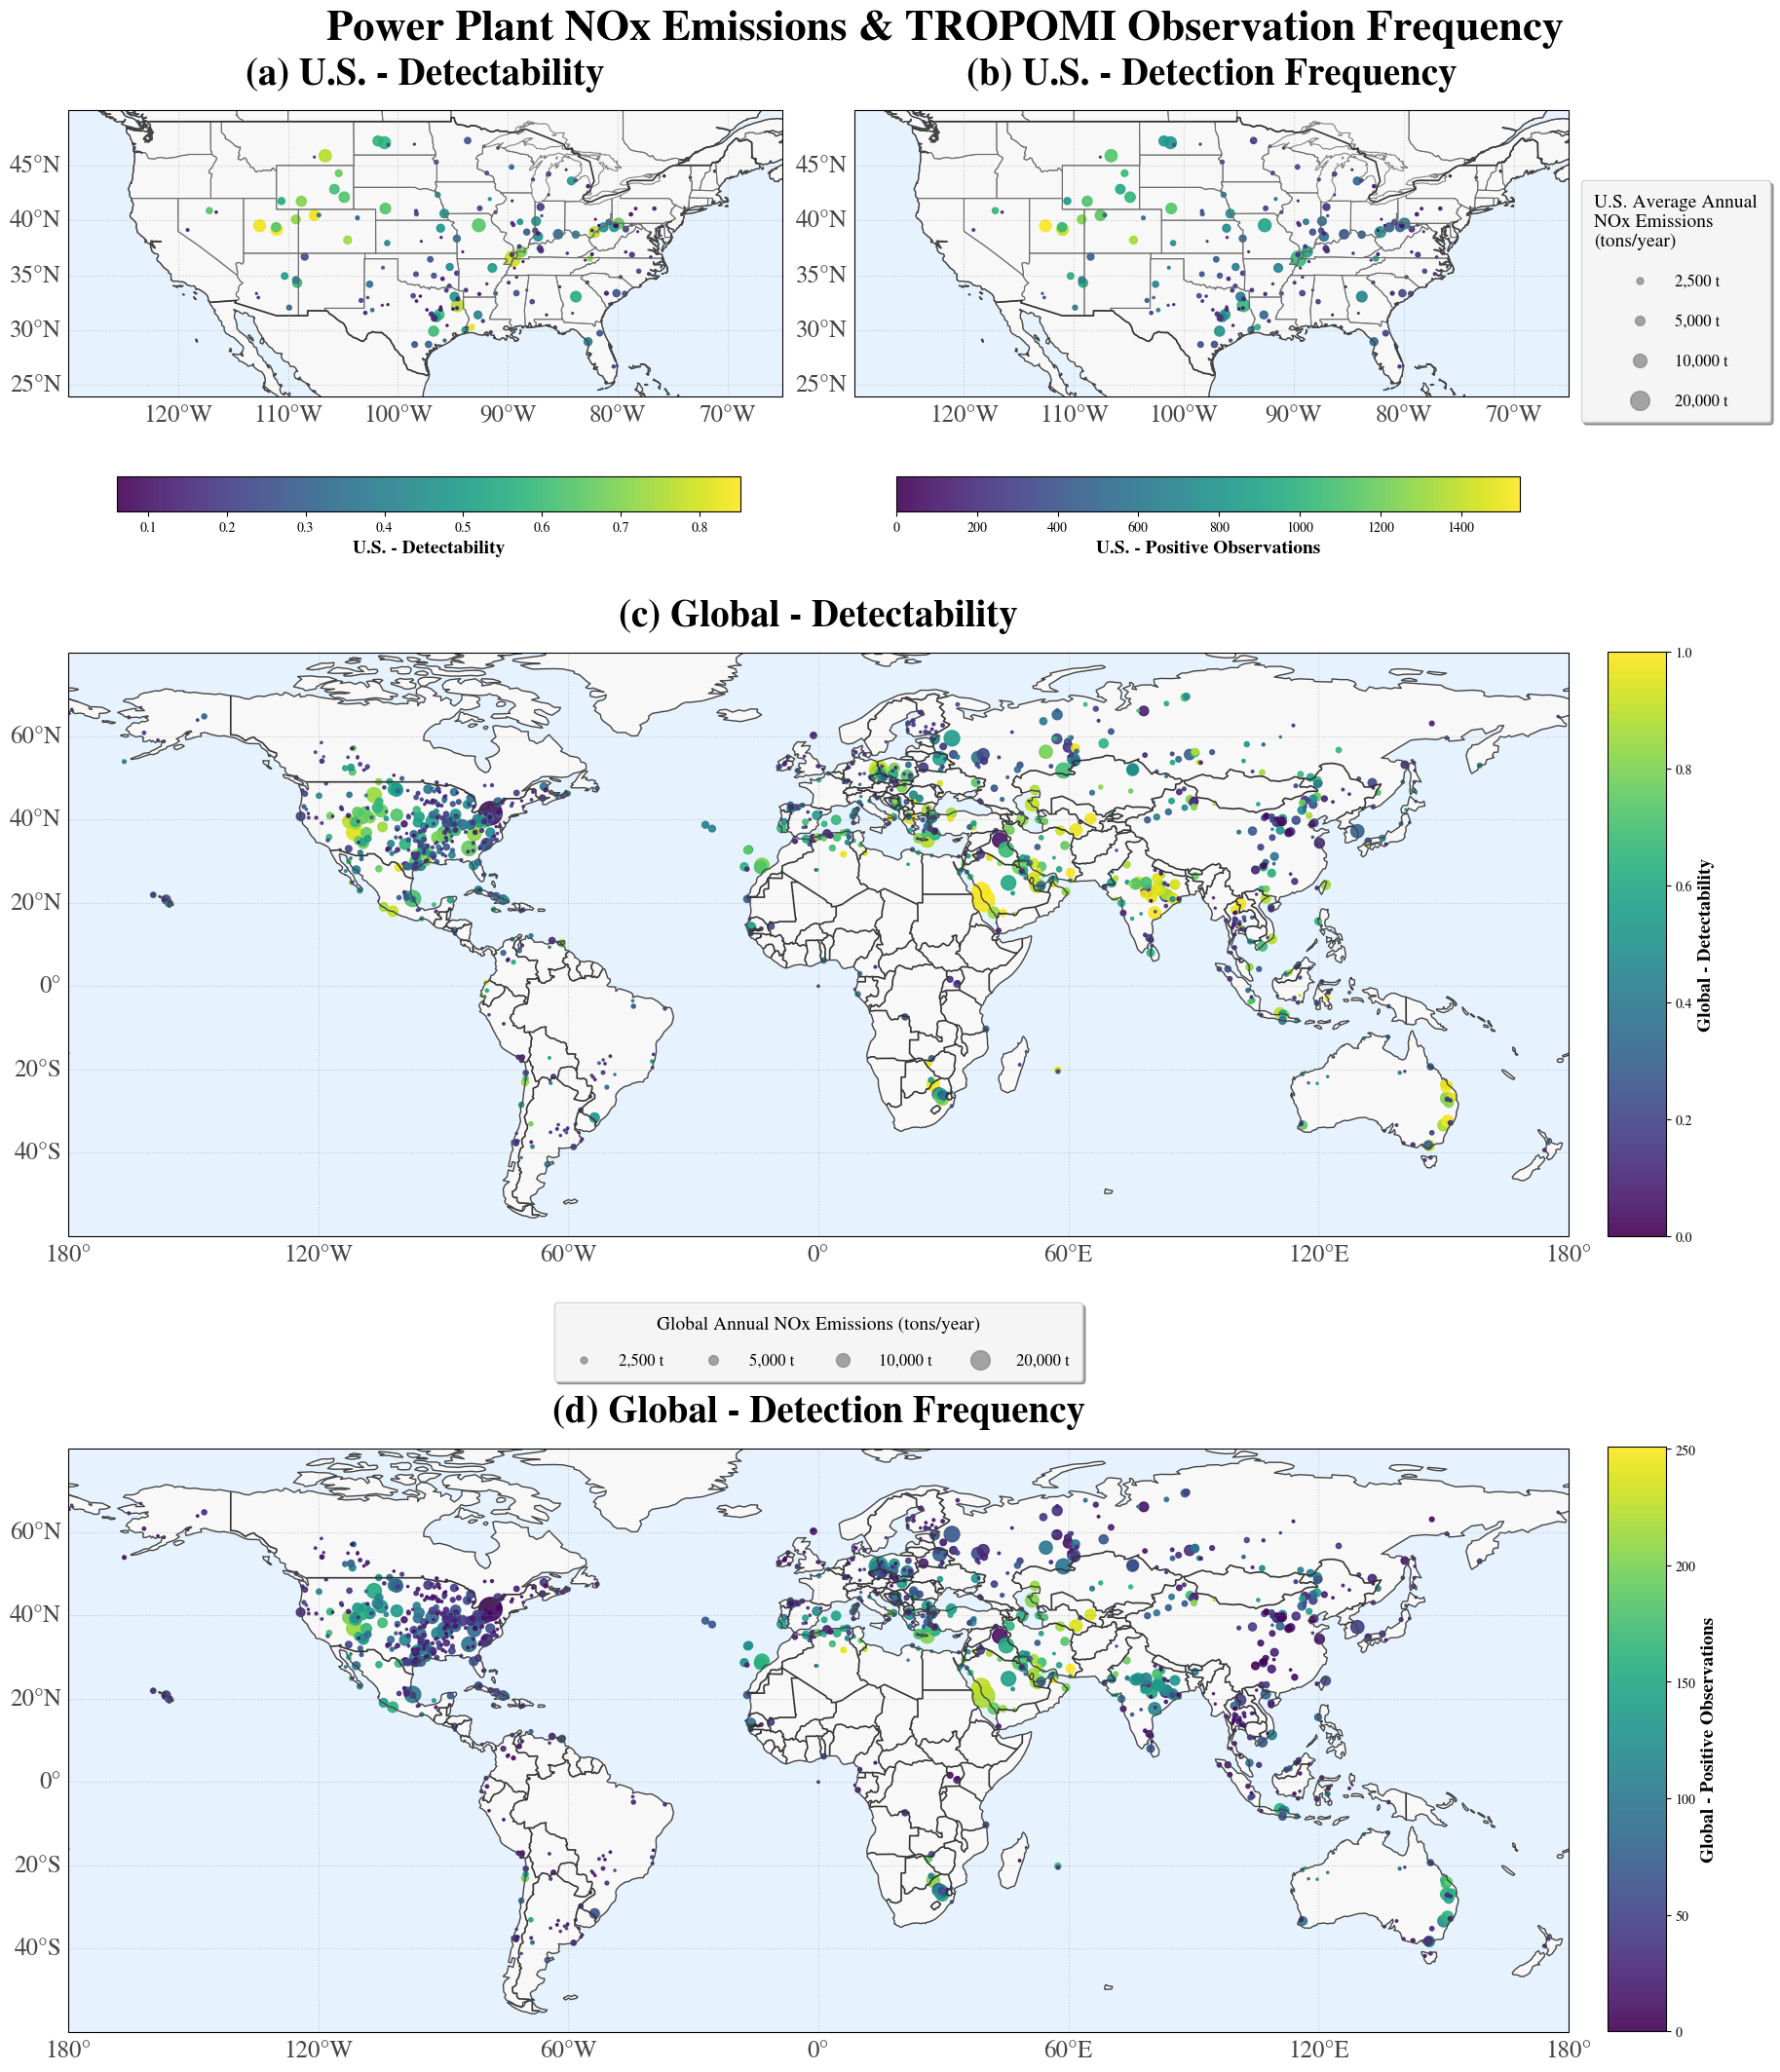


Plotting complete!
Output saved to: /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/Detection_Frequency_Plume_Probability_Filtered.pdf


In [4]:
# =========================
# Plot
# =========================
print("\n" + "="*60)
print("SUMMARY STATISTICS (After Interference Zone Filtering)")
print("="*60)
print(f"US Plants (6y & non-interfered): {len(us_gdf_filtered)} "
      f"(base complete-6y set: {len(complete_6y_ids)})")
print(f"Global Plants: {len(global_gdf_filtered)} (removed {len(set(map(str, global_interfered)))} interfered)")

us_norm_counts = mcolors.Normalize(vmin=0, vmax=max(1, us_gdf_filtered['pos_cnt'].max() if len(us_gdf_filtered) else 1))
us_norm_prob = mcolors.Normalize(
    vmin=(us_gdf_filtered['plume_probability'].min() if len(us_gdf_filtered) else 0),
    vmax=max(1e-9, us_gdf_filtered['plume_probability'].max() if len(us_gdf_filtered) else 1e-9)
)
prob_nonzero = global_gdf_filtered['plume_probability'][global_gdf_filtered['plume_probability'] > 0]
global_norm_prob = mcolors.Normalize(vmin=0, vmax=(global_gdf_filtered['plume_probability'].max() if len(global_gdf_filtered) else 1))
global_norm_counts = mcolors.Normalize(vmin=0, vmax=(global_gdf_filtered['pos_cnt'].max() if len(global_gdf_filtered) else 1))

fig = plt.figure(figsize=(20, 24))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1.5, 1.5], hspace=0.3, wspace=0.1,
                      top=0.94, bottom=0.08, left=0.05, right=0.82)

fig.suptitle('Power Plant NOx Emissions & TROPOMI Observation Frequency',
             fontsize=32, y=0.955, weight='bold', color="#000000")

def style_us_map(ax, title):
    ax.set_extent([-130, -65, 24, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#f8f8f8', edgecolor='none')
    ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
    ax.add_feature(cfeature.STATES, linewidth=0.8, edgecolor='#666666', alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=1.2, edgecolor='#333333')
    ax.coastlines(linewidth=1.0, color='#444444')
    gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.4, linewidth=0.8, color='#888888')
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {'size': 18, 'color': '#444444'}
    gl.ylabel_style = {'size': 18, 'color': '#444444'}
    ax.set_title(title, fontsize=28, fontweight='bold', pad=20)

def style_global_map(ax, title):
    ax.set_extent([-180, 180, -60, 80], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#f8f8f8', edgecolor='none')
    ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
    ax.add_feature(cfeature.BORDERS, linewidth=1.2, edgecolor='#333333')
    ax.coastlines(linewidth=1.0, color='#444444')
    gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.4, linewidth=0.8, color='#888888')
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {'size': 18, 'color': '#444444'}
    gl.ylabel_style = {'size': 18, 'color': '#444444'}
    ax.set_title(title, fontsize=28, fontweight='bold', pad=20)

# Row 1: U.S.
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
style_us_map(ax1, "(a) U.S. - Detectability")
sc1 = ax1.scatter(
    us_gdf_filtered["Longitude"], us_gdf_filtered["Latitude"],
    s=us_gdf_filtered["NOx_mass_scaled"],
    c=us_gdf_filtered['plume_probability'],
    cmap='viridis', norm=us_norm_prob, alpha=0.9, marker='o', transform=ccrs.PlateCarree()
)

ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
style_us_map(ax2, "(b) U.S. - Detection Frequency")
sc2 = ax2.scatter(
    us_gdf_filtered["Longitude"], us_gdf_filtered["Latitude"],
    s=us_gdf_filtered["NOx_mass_scaled"],
    c=us_gdf_filtered['pos_cnt'],
    cmap='viridis', norm=us_norm_counts, alpha=0.9, marker='o', transform=ccrs.PlateCarree()
)

# Row 2: Global probability
ax3 = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())
style_global_map(ax3, "(c) Global - Detectability")
sc3 = ax3.scatter(
    global_gdf_filtered["longitude"], global_gdf_filtered["latitude"],
    s=global_gdf_filtered["NOx_mass_scaled"],
    c=global_gdf_filtered['plume_probability'],
    cmap='viridis', norm=global_norm_prob, alpha=0.9, marker='o', transform=ccrs.PlateCarree()
)

# Row 3: Global frequency
ax4 = fig.add_subplot(gs[2, :], projection=ccrs.PlateCarree())
style_global_map(ax4, "(d) Global - Detection Frequency")
sc4 = ax4.scatter(
    global_gdf_filtered["longitude"], global_gdf_filtered["latitude"],
    s=global_gdf_filtered["NOx_mass_scaled"],
    c=global_gdf_filtered['pos_cnt'],
    cmap='viridis', norm=global_norm_counts, alpha=0.9, marker='o', transform=ccrs.PlateCarree()
)

# Colorbars
cbar_ax1 = fig.add_axes([0.075, 0.74, 0.32, 0.015])
cbar1 = fig.colorbar(sc1, cax=cbar_ax1, orientation='horizontal')
cbar1.set_label('U.S. - Detectability', fontsize=14, fontweight='bold')

cbar_ax2 = fig.add_axes([0.475, 0.74, 0.32, 0.015])
cbar2 = fig.colorbar(sc2, cax=cbar_ax2, orientation='horizontal')
cbar2.set_label('U.S. - Positive Observations', fontsize=14, fontweight='bold')

cbar_ax3 = fig.add_axes([0.84, 0.43, 0.03, 0.25])
cbar3 = fig.colorbar(sc3, cax=cbar_ax3, orientation='vertical')
cbar3.set_label('Global - Detectability', fontsize=14, fontweight='bold')

cbar_ax4 = fig.add_axes([0.84, 0.09, 0.03, 0.25])
cbar4 = fig.colorbar(sc4, cax=cbar_ax4, orientation='vertical')
cbar4.set_label('Global - Positive Observations', fontsize=14, fontweight='bold')

# Legends
us_sizes = [25, 50, 100, 200]
us_labels = [f'{int(s/us_nox_scaling_factor):,} t' for s in us_sizes]
us_handles = [plt.scatter([], [], s=s, c='gray', alpha=0.7) for s in us_sizes]
us_legend = fig.legend(
    us_handles, us_labels, borderpad=0.8,
    title='U.S. Average Annual\nNOx Emissions\n(tons/year)', ncol=1, labelspacing=1.5,
    loc='upper center', bbox_to_anchor=(0.875, 0.885),
    fontsize=12, title_fontsize=14, frameon=True, fancybox=True, shadow=True,
    handletextpad=1.2, columnspacing=2
)

glb_sizes = [25, 50, 100, 200]
glb_labels = [f'{int(s/global_nox_scaling_factor):,} t' for s in glb_sizes]
glb_handles = [plt.scatter([], [], s=s, c='gray', alpha=0.7) for s in glb_sizes]
global_legend = fig.legend(
    glb_handles, glb_labels, borderpad=0.8,
    title='Global Annual NOx Emissions (tons/year)', labelspacing=1.2, ncol=len(glb_handles),
    loc='upper center', bbox_to_anchor=(0.435, 0.405),
    fontsize=12, title_fontsize=14, frameon=True, fancybox=True, shadow=True,
    handletextpad=1.2, columnspacing=2
)
for legend in [us_legend, global_legend]:
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)

out_path = os.path.join(OUTPUT_DIR, 'Detection_Frequency_Plume_Probability_Filtered.pdf')
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

print("\n" + "="*60)
print("Plotting complete!")
print(f"Output saved to: {out_path}")
print("="*60)
